In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [165]:
df = pd.read_csv("data/outputs/all_indicator_values.csv")

In [141]:
# Target
target = (
    df[df["indicator"] == "CompositeRisk"]
    [["country", "year", "value"]]
    .rename(columns={"value": "CompositeRisk"})
)

# Features
features = df[df["indicator"] != "CompositeRisk"].copy()


In [116]:
features = features.pivot(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()

features["Economic"] = 1 - features["Economic"]
features["Governance"] = 1 - features["Governance"]
features["Social"] = 1 - features["Social"]


In [117]:
features

indicator,country,year,Capacity,Economic,Ecosystems,Exposure,Food,Governance,Habitat,Health,Infrastructure,Readiness,Sensitivity,Social,Vulnerability,Water
0,AFG,1995,0.893281,0.503503,0.515884,0.480512,0.665745,0.871910,0.602933,0.748302,0.355586,0.308182,0.419587,0.700042,0.591376,0.529692
1,AFG,1996,0.893892,0.503503,0.516995,0.480512,0.665583,0.871910,0.604235,0.748302,0.354484,0.308180,0.419307,0.700046,0.591385,0.528281
2,AFG,1997,0.894459,0.503503,0.518030,0.480512,0.665420,0.858608,0.605583,0.748302,0.353925,0.312614,0.419055,0.700048,0.591453,0.526853
3,AFG,1998,0.890161,0.503503,0.518156,0.480512,0.657103,0.845306,0.606909,0.748302,0.353710,0.317047,0.418794,0.700051,0.589820,0.525424
4,AFG,1999,0.885896,0.503503,0.518156,0.480512,0.648959,0.856311,0.608137,0.748302,0.352292,0.313378,0.419433,0.700053,0.588345,0.525585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8551,ZWE,2036,0.588863,0.715092,0.499704,0.516912,0.572403,0.819337,0.560557,0.694479,0.315343,0.202295,0.410264,0.858686,0.501943,0.373934
8552,ZWE,2037,0.590097,0.714175,0.498560,0.516912,0.572504,0.818073,0.560353,0.694478,0.317924,0.203015,0.409847,0.858707,0.502245,0.374200
8553,ZWE,2038,0.591269,0.713353,0.497488,0.516912,0.572582,0.817073,0.560210,0.694477,0.320331,0.203615,0.409477,0.858729,0.502543,0.374514
8554,ZWE,2039,0.592382,0.712615,0.496494,0.516912,0.572643,0.816294,0.560125,0.694476,0.322576,0.204114,0.409147,0.858750,0.502835,0.374835


In [118]:
dataset = features.merge(target, on=["country", "year"])
dataset = dataset.set_index(["country", "year"])

# Exclude composite metrics that dominate the target
excluded_features = ["Vulnerability", "Readiness"]
dataset = dataset.drop(columns=excluded_features)

In [119]:
test_years = 5

train = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[:-test_years])
           .reset_index(level=0, drop=True)
)

test = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[-test_years:])
           .reset_index(level=0, drop=True)
)

X_train = train.drop(columns="CompositeRisk")
y_train = train["CompositeRisk"]

X_test = test.drop(columns="CompositeRisk")
y_test = test["CompositeRisk"]

In [120]:
# No readiness correction needed because Readiness is excluded
X_corrected_train = X_train.copy()
X_corrected_test = X_test.copy()

In [121]:
# Approach A: Train on original indicators
rf_corrected = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [122]:
rf_corrected.fit(X_corrected_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [123]:
y_pred_corr = rf_corrected.predict(X_corrected_test)
r2_corrected = r2_score(y_test, y_pred_corr)
print(f"RF (excluding Vulnerability & Readiness): R² = {r2_corrected:.4f}")


RF (excluding Vulnerability & Readiness): R² = 0.9978


In [124]:
# Approach B: Train on PCA components
pca = PCA()
pca.fit(X_corrected_train)

X_pca_train = pca.transform(X_corrected_train)
X_pca_test = pca.transform(X_corrected_test)

rf_pca = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_pca_train, y_train)
y_pred_pca = rf_pca.predict(X_pca_test)

# Compare performance
print("Original Indicators:")
print(f"  R² Score: {r2_score(y_test, y_pred_corr):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_corr):.4f}")

print("\nPCA Components:")
print(f"  R² Score: {r2_score(y_test, y_pred_pca):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_pca):.4f}")

/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-p

Original Indicators:
  R² Score: 0.9978
  MAE: 0.0017

PCA Components:
  R² Score: 0.9974
  MAE: 0.0017


In [125]:
feature_names = X.columns

In [126]:
# Feature importance
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_corrected.feature_importances_,
    "PC1_Loading": np.abs(pca.components_[0][:len(feature_names)])
}).sort_values("RF_Importance", ascending=False)

print(importance_df)

           Feature  RF_Importance  PC1_Loading
7           Health       0.337005     0.423258
4             Food       0.314131     0.348569
0         Capacity       0.104699     0.426136
3         Exposure       0.085806     0.097993
9      Sensitivity       0.047742     0.145631
8   Infrastructure       0.027683     0.057691
5       Governance       0.023620     0.504713
1         Economic       0.019954     0.251039
11           Water       0.013344     0.115923
2       Ecosystems       0.010241     0.165673
6          Habitat       0.007997     0.154796
10          Social       0.007776     0.317834


In [127]:
print(len(feature_names))
print(len(rf_corrected.feature_importances_))
print(len(pca.components_[0]))

12
12
12


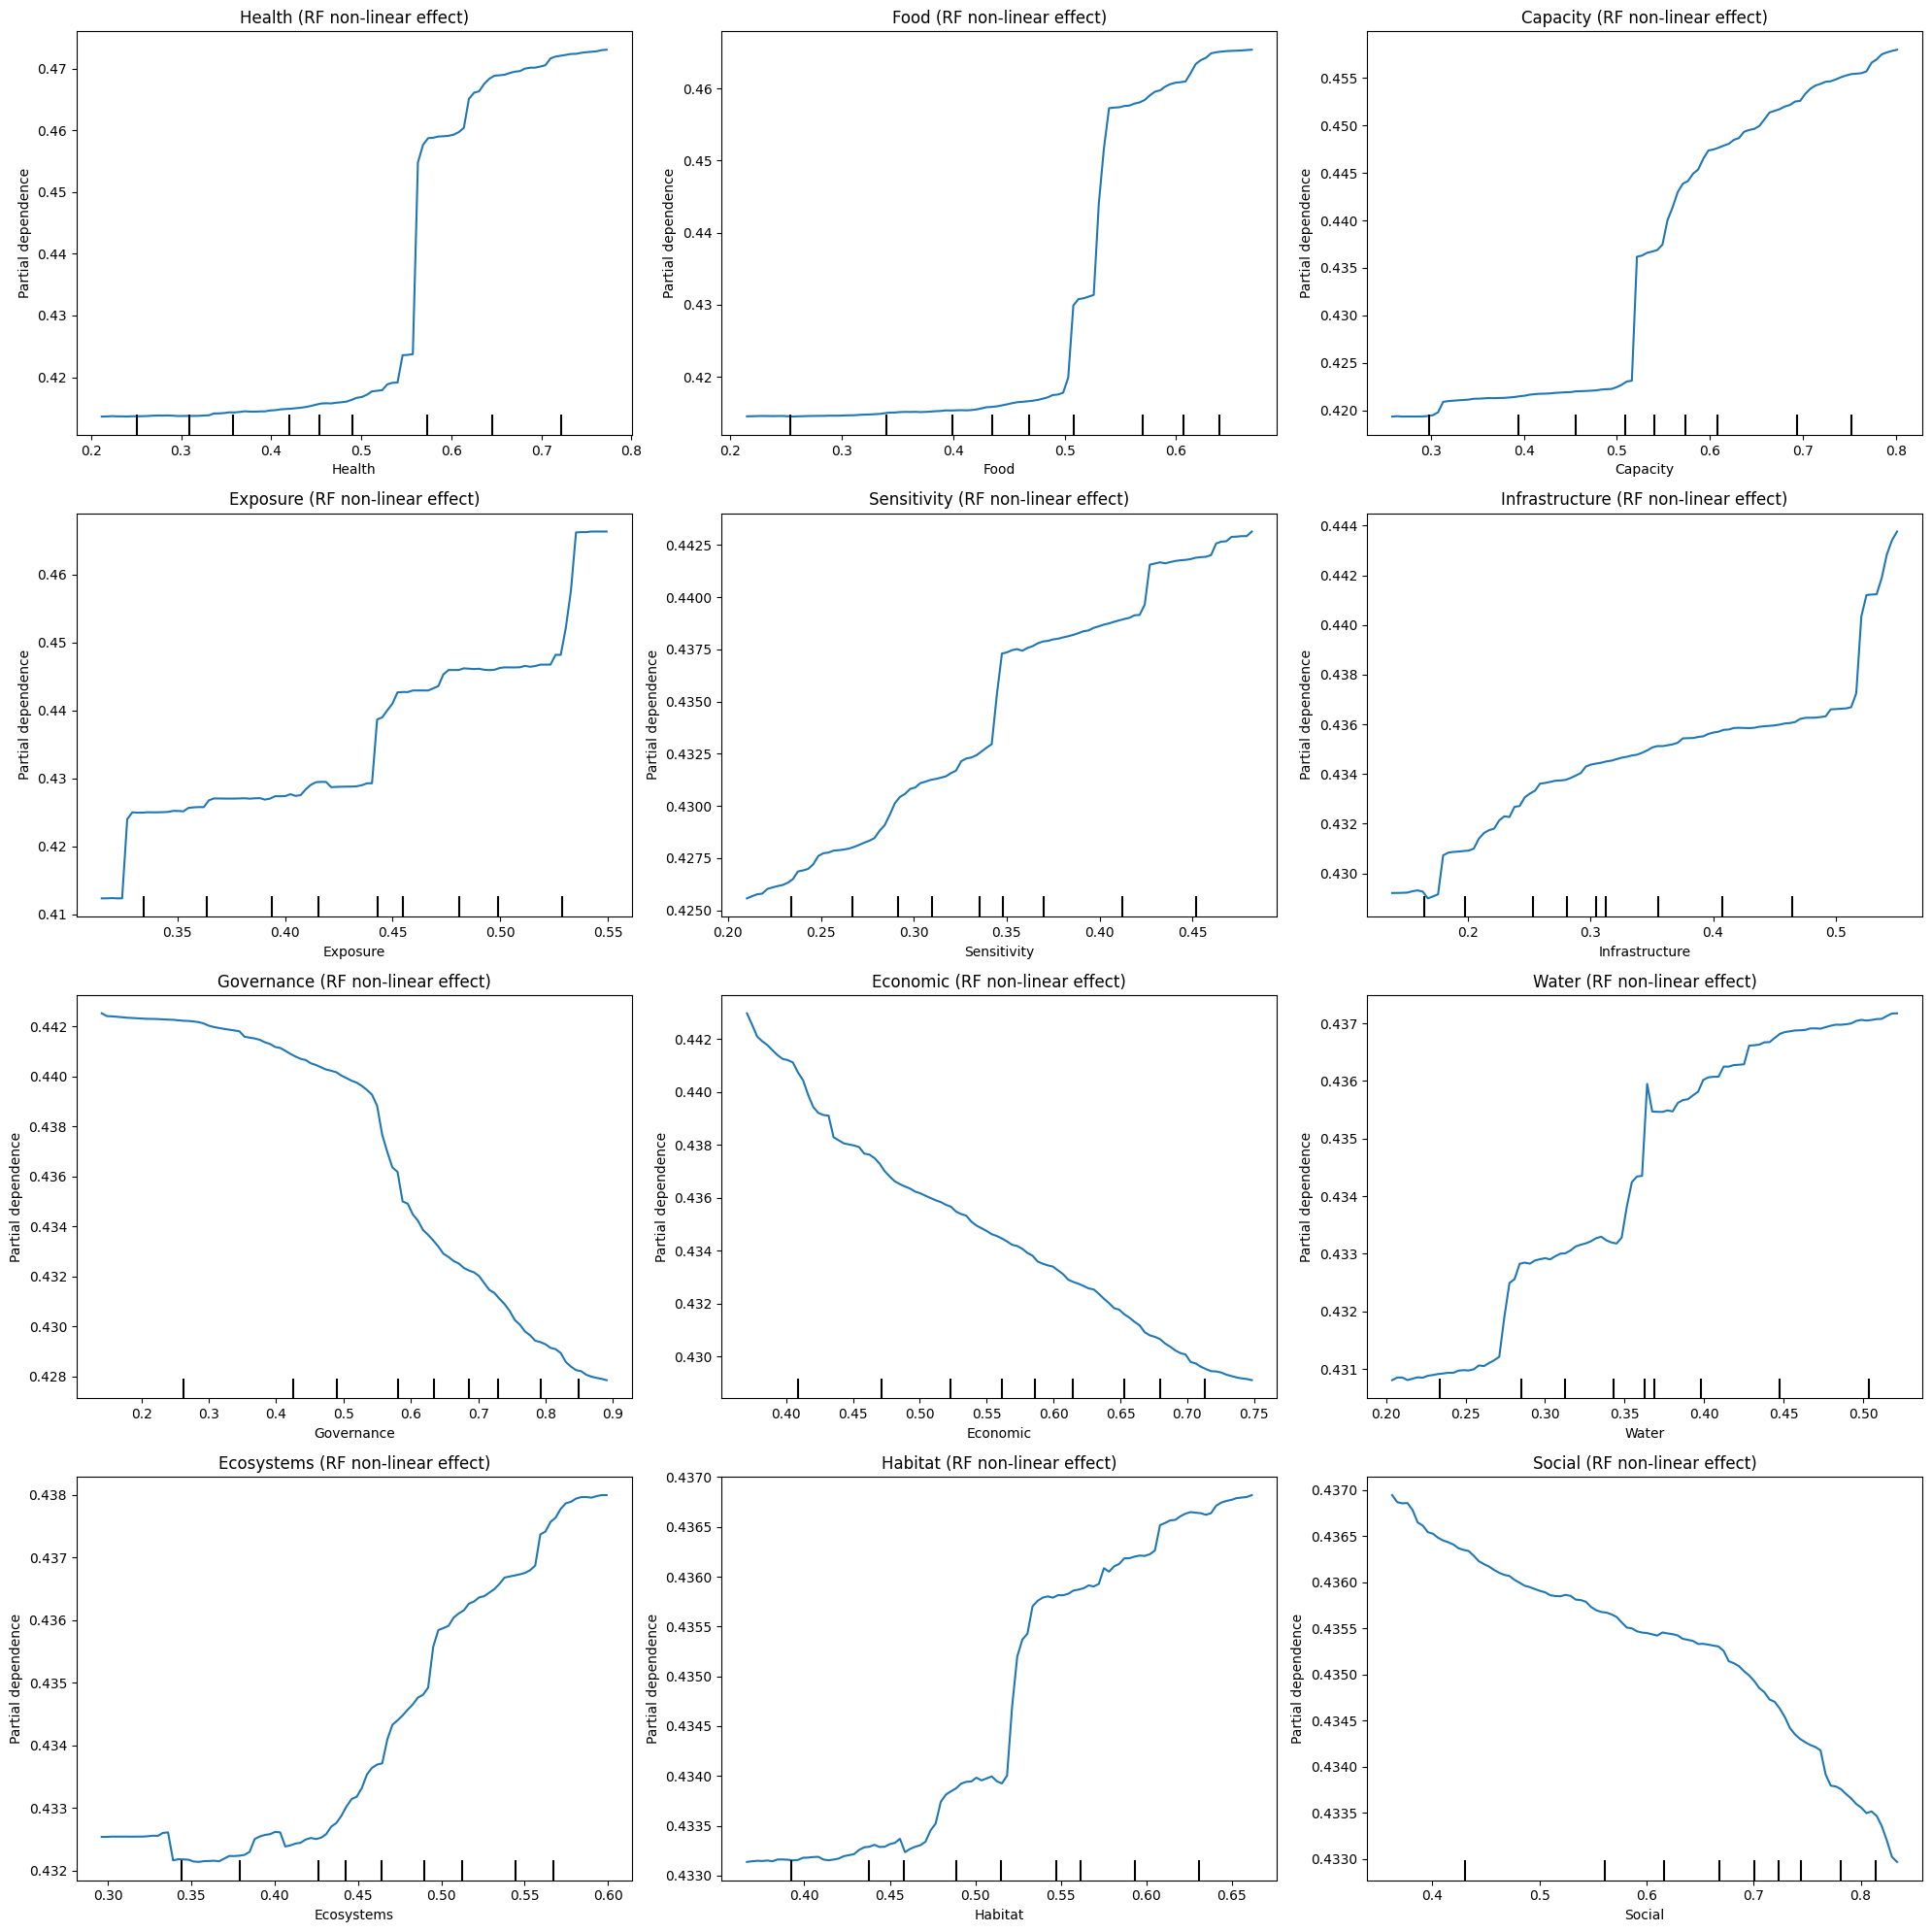

In [128]:
# Partial dependence plots for top 4 features (original approach)
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
top_features_idx = importance_df.head(12).index.values

for idx, ax in enumerate(axes.flat):
    feature_idx = top_features_idx[idx]
    PartialDependenceDisplay.from_estimator(
        rf_corrected, X_corrected_test, [feature_idx], ax=ax
    )
    ax.set_title(f"{feature_names[feature_idx]} (RF non-linear effect)")

plt.tight_layout()
plt.show()

In [129]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_corrected)  # Your corrected RF model

# Calculate SHAP values for all test data
shap_values = explainer.shap_values(X_corrected_test)

# Create base value (model's average prediction)
base_value = explainer.expected_value

explanation = shap.Explanation(
    values = shap_values,
    base_values=explainer.expected_value,
    feature_names=X_corrected_test.columns.tolist()
)

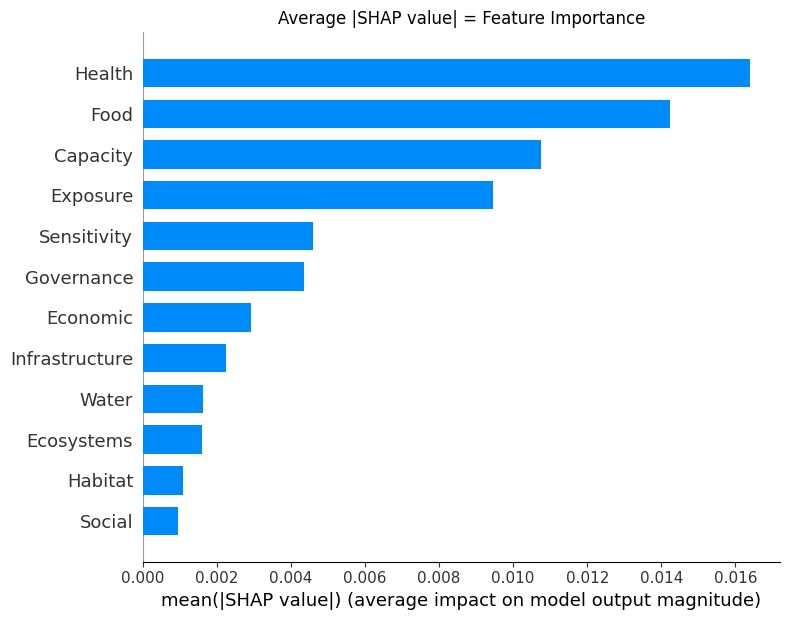

In [130]:
# Bar plot: average absolute impact
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_corrected_test,
    plot_type="bar",
    show=False
)
plt.title("Average |SHAP value| = Feature Importance")
plt.tight_layout()
plt.show()

In [131]:
X_corrected_test.iloc[0:10,:]

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     2036  0.693118  0.705410    0.512293  0.480512  0.599771    0.880467   
        2037  0.694491  0.702018    0.512394  0.480512  0.600715    0.881136   
        2038  0.695842  0.698923    0.512484  0.480512  0.601608    0.881693   
        2039  0.697174  0.696099    0.512565  0.480512  0.602453    0.882157   
        2040  0.698485  0.693521    0.512637  0.480512  0.603251    0.882545   
AGO     2036  0.752054  0.766305    0.543362  0.543063  0.575920    0.824365   
        2037  0.752047  0.766545    0.543360  0.543063  0.576888    0.826105   
        2038  0.752039  0.766742    0.543360  0.543063  0.577811    0.827498   
        2039  0.752032  0.766904    0.543359  0.543063  0.578691    0.828611   
        2040  0.752027  0.767036    0.543359  0.543063  0.579531    0.829501   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     2036  0.566048  0.783486        0.303842     0.431856  0.660031   
        2037  0.567743  0.782774        0.304675     0.431739  0.661411   
        2038  0.569111  0.782167        0.305480     0.431651  0.662729   
        2039  0.570168  0.781649        0.306258     0.431584  0.663978   
        2040  0.570938  0.781208        0.307009     0.431534  0.665154   
AGO     2036  0.675208  0.602390        0.311406     0.275776  0.831335   
        2037  0.674715  0.601551        0.311428     0.275249  0.834832   
        2038  0.674217  0.600728        0.311431     0.274737  0.838072   
        2039  0.673762  0.599921        0.311425     0.274241  0.841034   
        2040  0.673302  0.599128        0.311417     0.273760  0.843705   

                 Water  
country year            
AFG     2036  0.504409  
        2037  0.505372  
        2038  0.506331  
        2039  0.507278  
        2040  0.508208  
AGO     2036  0.330221  
        2037  0.330203  
        2038  0.330189  
        2039  0.330179  
        2040  0.330172

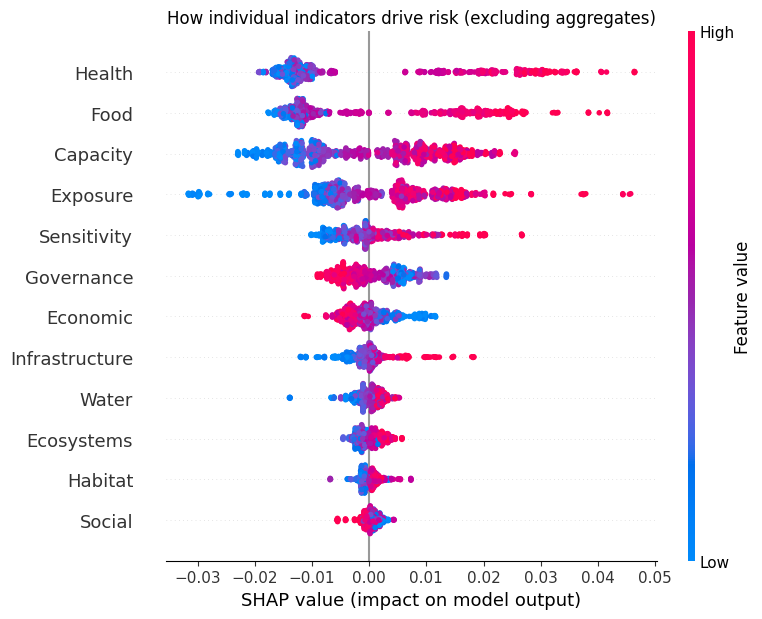

In [132]:
# Shows: high score → increases risk (right), low score → decreases risk (left)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_corrected_test,
    plot_type="dot",
    show=False
)
plt.title("How individual indicators drive risk (excluding aggregates)")
plt.tight_layout()
plt.show()

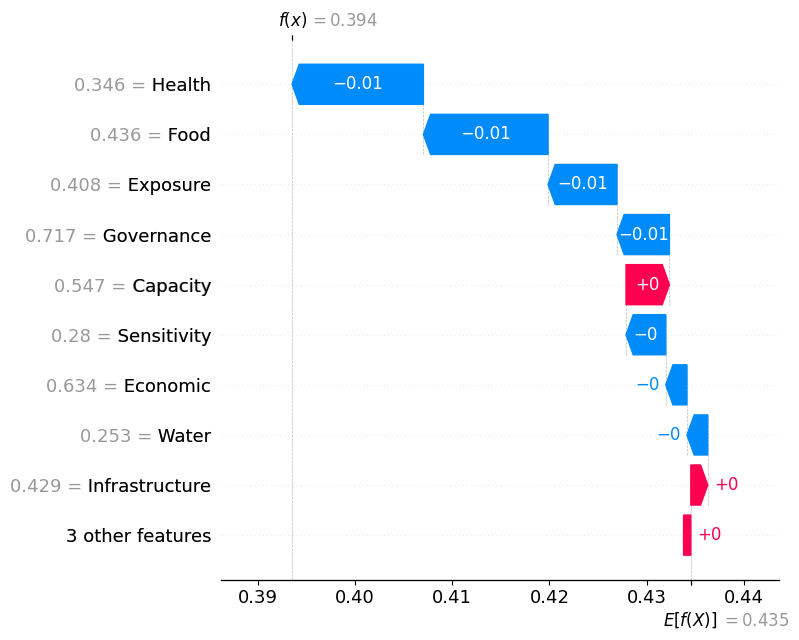

In [133]:
# Get SHAP values for a single country
country_idx = 10  # Pick a country
single_instance = X_corrected_test.iloc[country_idx:country_idx+1]
shap_values_single = explainer.shap_values(single_instance)

# Create waterfall plot correctly
explanation = shap.Explanation(
    values=shap_values_single[0],  # Get first (and only) row
    base_values=explainer.expected_value,
    data=single_instance.values[0],  # Convert to numpy array
    feature_names=X_corrected_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.show()

In [134]:
def explain_country_risk(country, model, explainer, data, year=None):

    # Get the requested row
    if year is None:
        row = data.loc[[country]].iloc[[0]]
    else:
        row = data.loc[[(country, year)]]

    # Prediction
    pred = model.predict(row)[0]

    # SHAP values
    shap_values = explainer.shap_values(row)

    explanation = (
        pd.DataFrame({
            "Feature": row.columns,
            "SHAP_Value": shap_values[0]
        })
        .sort_values("SHAP_Value", key=np.abs, ascending=False)
    )

    explanation["Contribution (%)"] = (
        explanation["SHAP_Value"].abs()
        / explanation["SHAP_Value"].abs().sum()
        * 100
    )

    print(f"\nPrediction: {pred:.4f}")
    print(f"Country: {row.index[0][0]}")
    print(f"Year: {row.index[0][1]}\n")

    return explanation

In [135]:
explain_country_risk("TCD", rf_corrected, explainer, X_corrected_test, year=2036)


Prediction: 0.5142
Country: TCD
Year: 2036



,Feature,SHAP_Value,Contribution (%)
7,Health,0.029042,28.309290
4,Food,0.024279,23.666932
0,Capacity,0.020233,19.723244
3,Exposure,0.011693,11.398271
1,Economic,-0.005391,5.254585
5,Governance,-0.004580,4.464302
2,Ecosystems,0.001949,1.899907
11,Water,0.001673,1.630709
9,Sensitivity,0.001658,1.616243
8,Infrastructure,-0.000960,0.935595


<Figure size 1000x600 with 0 Axes>

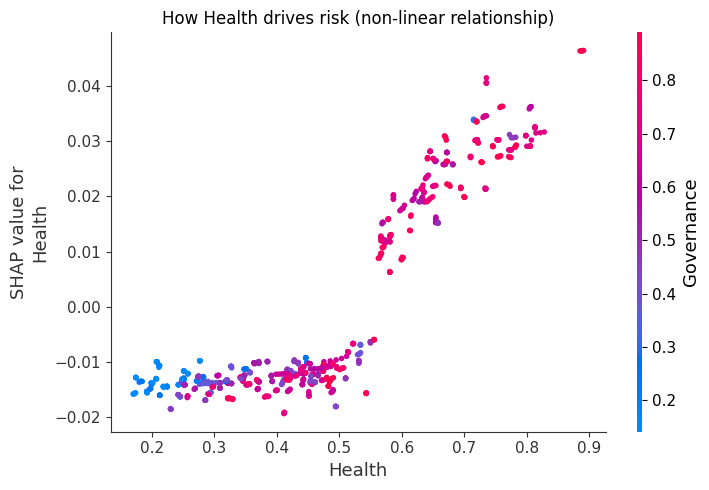

In [136]:
# Top contributor by SHAP impact
top_feature_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feature_name = X_corrected_test.columns[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_corrected_test,
    show=False
)
plt.title(f"How {top_feature_name} drives risk (non-linear relationship)")
plt.tight_layout()
plt.show()

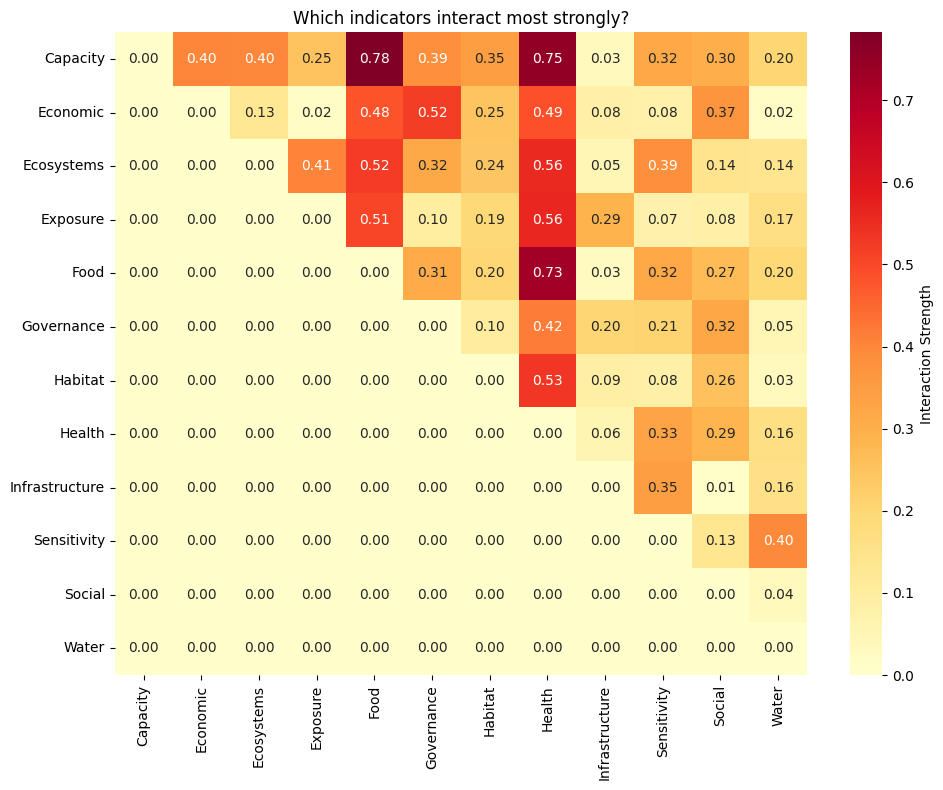

In [137]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============ FOCUS: Component-to-component interactions ============
# Exclude Vulnerability and Readiness from this analysis
components = [col for col in X_corrected_test.columns
              if col not in ['Vulnerability', 'Readiness']]

X_components_only = X_corrected_test[components]
shap_components = explainer.shap_values(X_components_only)


# ============ PLOT 2: Interaction heatmap ============
# Which component pairs interact most strongly?
interaction_matrix = np.zeros((len(components), len(components)))

for i, feat1 in enumerate(components):
    for j, feat2 in enumerate(components):
        if i < j:
            # Correlation between feature values × SHAP values = interaction proxy
            feat1_idx = X_corrected_test.columns.get_loc(feat1)
            feat2_idx = X_corrected_test.columns.get_loc(feat2)
            interaction = np.corrcoef(
                X_components_only[feat1].values,
                shap_components[:, feat2_idx]
            )[0, 1]
            interaction_matrix[i, j] = abs(interaction)

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(interaction_matrix, xticklabels=components, yticklabels=components,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Interaction Strength'})
plt.title("Which indicators interact most strongly?")
plt.tight_layout()
plt.show()

In [142]:
X = dataset.drop(columns="CompositeRisk")

In [144]:
X

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
...                ...       ...         ...       ...       ...         ...   
ZWE     2036  0.588863  0.715092    0.499704  0.516912  0.572403    0.819337   
        2037  0.590097  0.714175    0.498560  0.516912  0.572504    0.818073   
        2038  0.591269  0.713353    0.497488  0.516912  0.572582    0.817073   
        2039  0.592382  0.712615    0.496494  0.516912  0.572643    0.816294   
        2040  0.593440  0.711952    0.495580  0.516912  0.572689    0.815697   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
...                ...       ...             ...          ...       ...   
ZWE     2036  0.560557  0.694479        0.315343     0.410264  0.858686   
        2037  0.560353  0.694478        0.317924     0.409847  0.858707   
        2038  0.560210  0.694477        0.320331     0.409477  0.858729   
        2039  0.560125  0.694476        0.322576     0.409147  0.858750   
        2040  0.560087  0.694476        0.324668     0.408854  0.858772   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
...                ...  
ZWE     2036  0.373934  
        2037  0.374200  
        2038  0.374514  
        2039  0.374835  
        2040  0.375134  

[8556 rows x 12 columns]

In [143]:
y = dataset["CompositeRisk"]


In [145]:
y

country  year
AFG      1995    0.536668
         1996    0.536782
         1997    0.538087
         1998    0.537887
         1999    0.535653
                   ...   
ZWE      2036    0.447177
         2037    0.447461
         2038    0.447716
         2039    0.447946
         2040    0.448154
Name: CompositeRisk, Length: 8556, dtype: float64

In [147]:
rf_corrected.fit(X,y)
y_pred = rf_corrected.predict(X)


In [148]:
# Approach B: Train on PCA components
pca = PCA()
pca.fit(X)

X_pca = pca.transform(X)

rf_pca = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X, y)
y_pred_pca = rf_pca.predict(X)


/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [149]:
feature_names = X.columns

In [150]:
# Feature importance
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_corrected.feature_importances_,
    "PC1_Loading": np.abs(pca.components_[0][:len(feature_names)])
}).sort_values("RF_Importance", ascending=False)

print(importance_df)

           Feature  RF_Importance  PC1_Loading
7           Health       0.407809     0.423921
4             Food       0.237828     0.348657
0         Capacity       0.102451     0.425497
3         Exposure       0.090590     0.098145
9      Sensitivity       0.054078     0.145417
5       Governance       0.025509     0.505345
8   Infrastructure       0.025261     0.055396
1         Economic       0.017832     0.250484
11           Water       0.013296     0.116337
2       Ecosystems       0.010316     0.166041
6          Habitat       0.007683     0.154761
10          Social       0.007345     0.317276


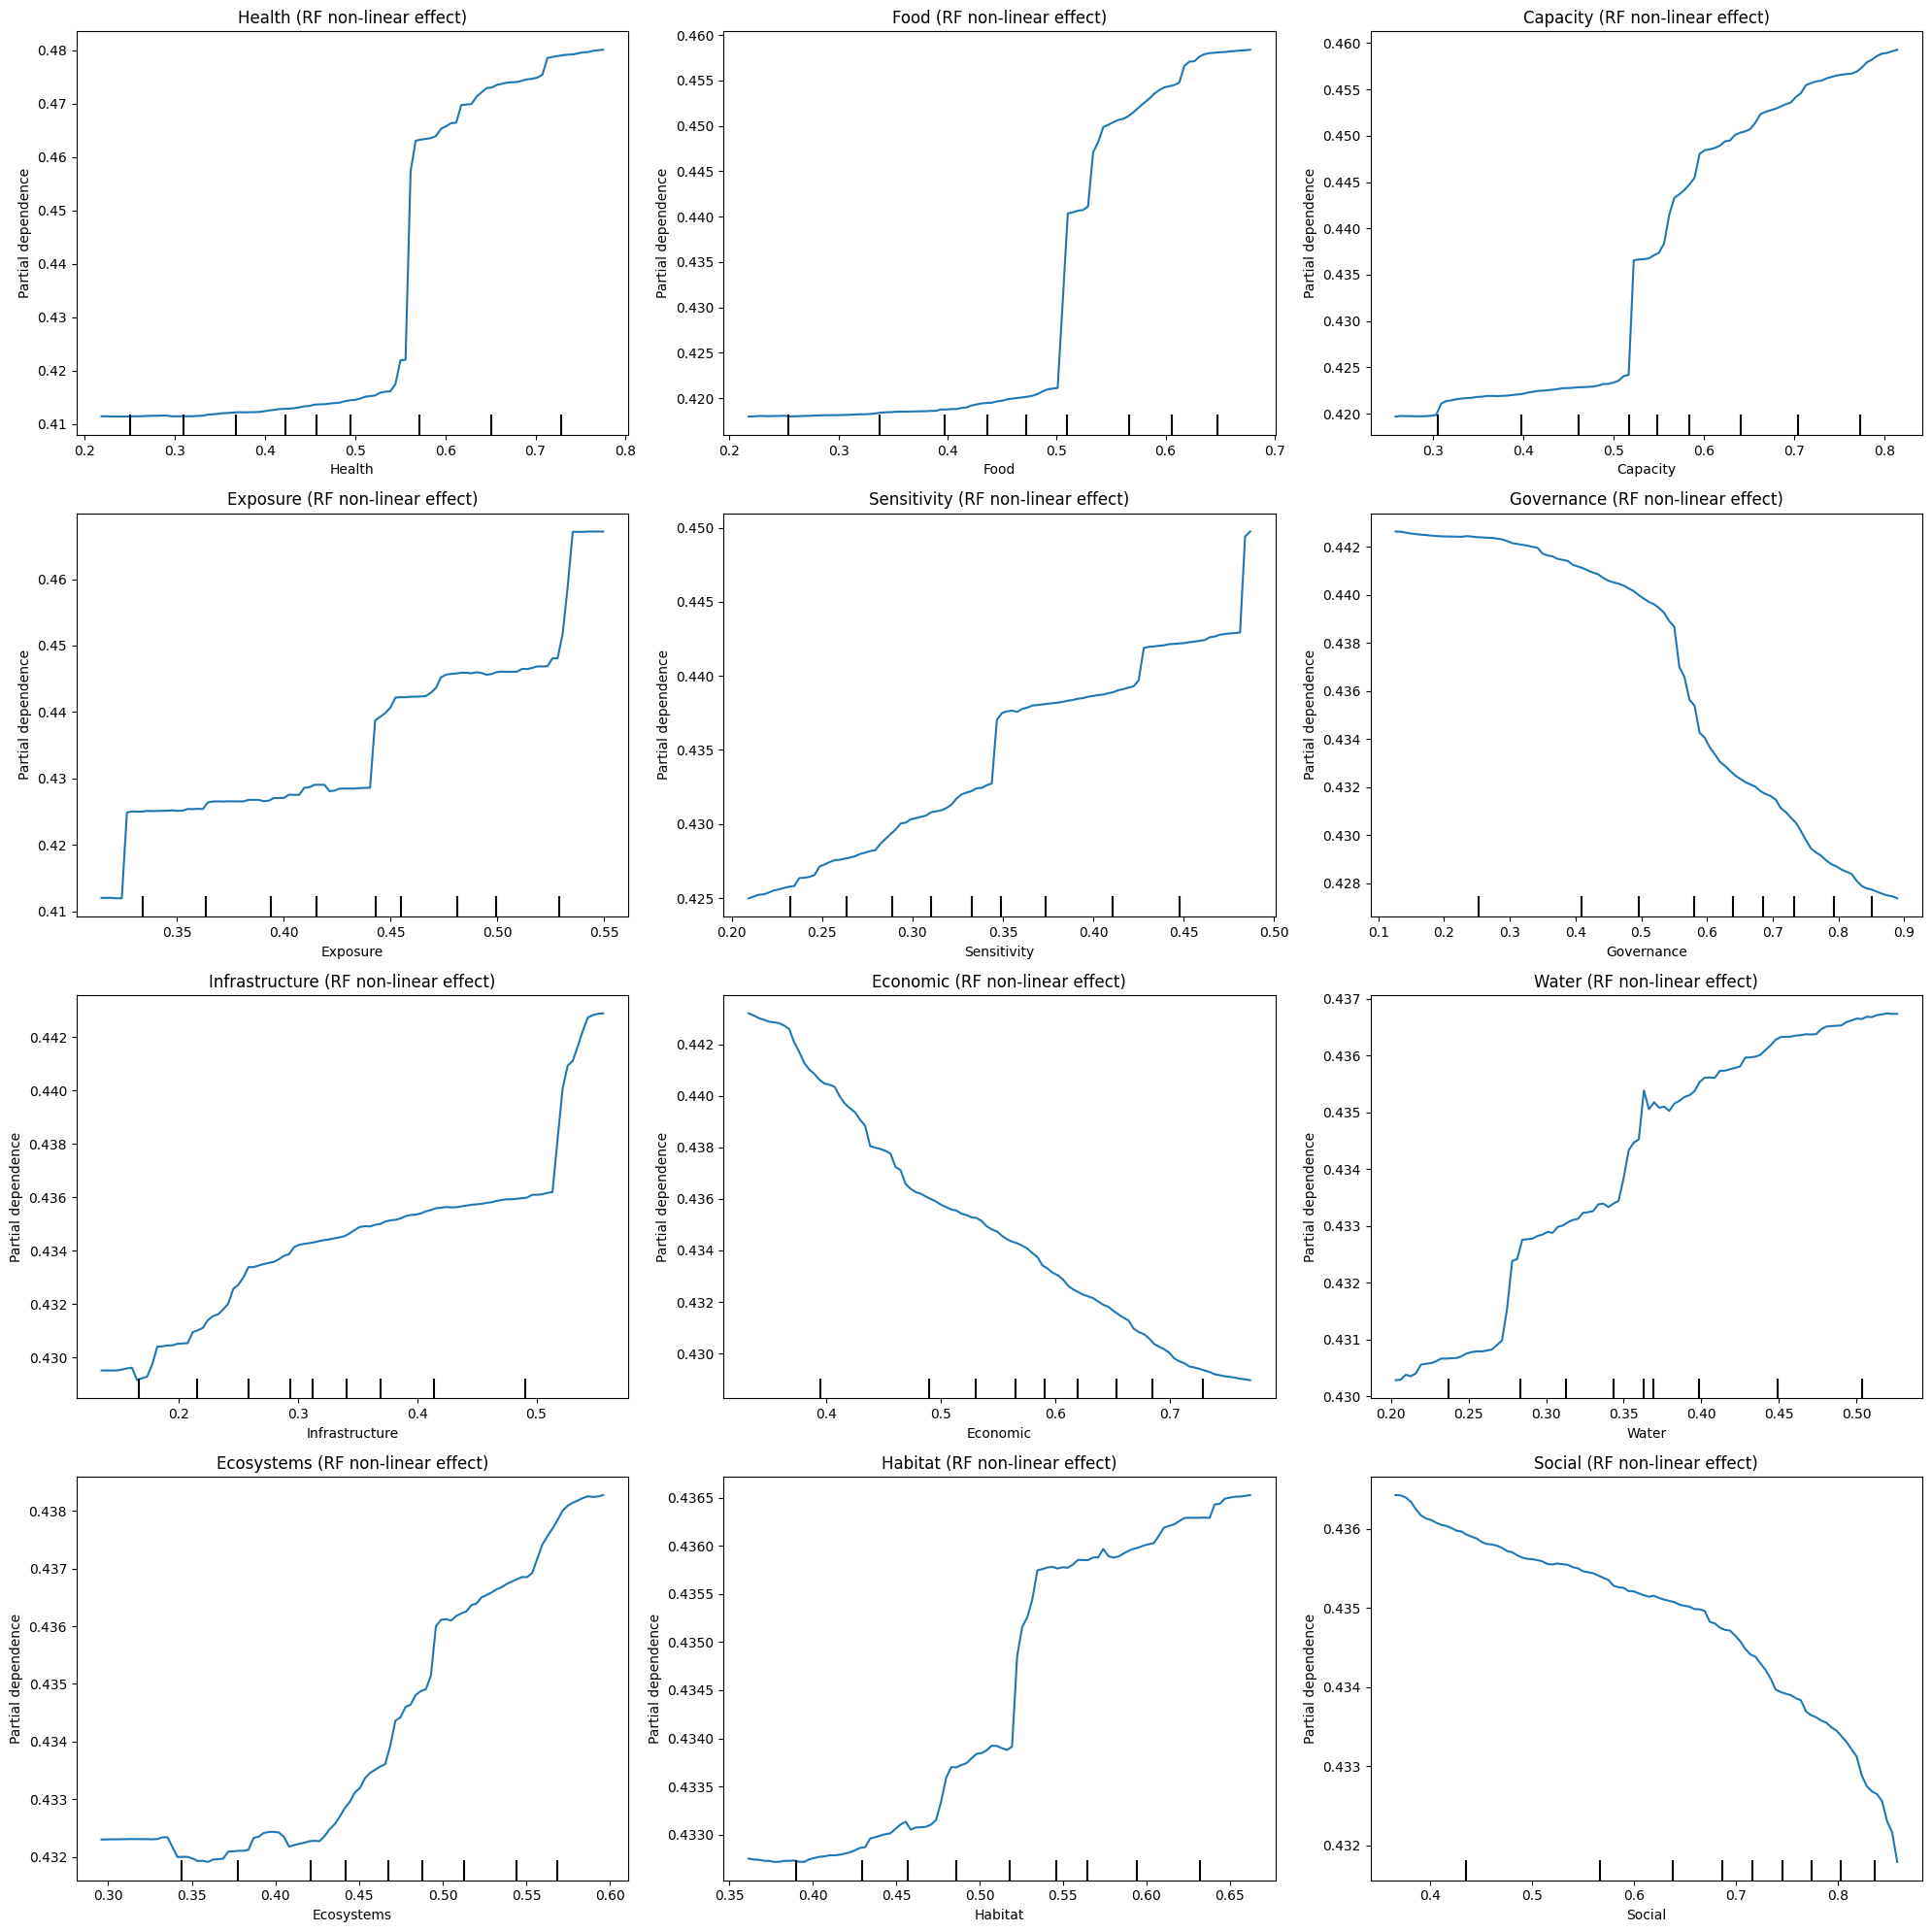

In [151]:
# Partial dependence plots for top 4 features (original approach)
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
top_features_idx = importance_df.head(12).index.values

for idx, ax in enumerate(axes.flat):
    feature_idx = top_features_idx[idx]
    PartialDependenceDisplay.from_estimator(
        rf_corrected, X, [feature_idx], ax=ax
    )
    ax.set_title(f"{feature_names[feature_idx]} (RF non-linear effect)")

plt.tight_layout()
plt.show()

In [152]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_corrected)  # Your corrected RF model

# Calculate SHAP values for all test data
shap_values = explainer.shap_values(X)

# Create base value (model's average prediction)
base_value = explainer.expected_value

explanation = shap.Explanation(
    values = shap_values,
    base_values=explainer.expected_value,
    feature_names=X.columns.tolist()
)

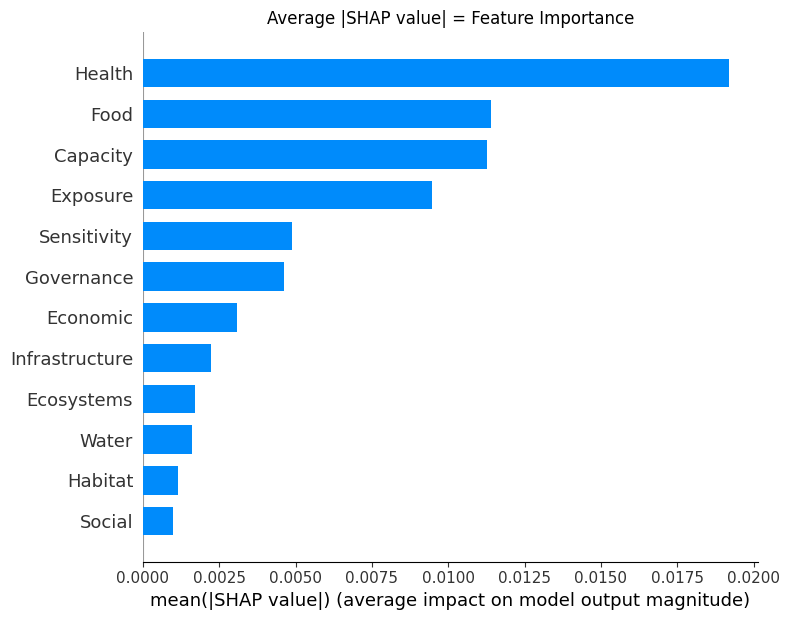

In [153]:
# Bar plot: average absolute impact
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)
plt.title("Average |SHAP value| = Feature Importance")
plt.tight_layout()
plt.show()

In [154]:
X.iloc[0:10,:]

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
        2000  0.881523  0.503503    0.518156  0.480512  0.640726    0.867315   
        2001  0.871661  0.503503    0.518156  0.480512  0.631250    0.864948   
        2002  0.861821  0.503503    0.518156  0.480512  0.622440    0.862581   
        2003  0.852440  0.503503    0.518156  0.480512  0.614618    0.883977   
        2004  0.842772  0.503503    0.518156  0.480512  0.606118    0.885464   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
        2000  0.609171  0.748302        0.352891     0.419954  0.700054   
        2001  0.609941  0.747669        0.351845     0.420319  0.700054   
        2002  0.610407  0.747669        0.350372     0.420499  0.700004   
        2003  0.610594  0.700842        0.349830     0.397099  0.699645   
        2004  0.610599  0.722573        0.349232     0.407808  0.698996   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
        2000  0.525637  
        2001  0.525648  
        2002  0.524336  
        2003  0.523046  
        2004  0.521640

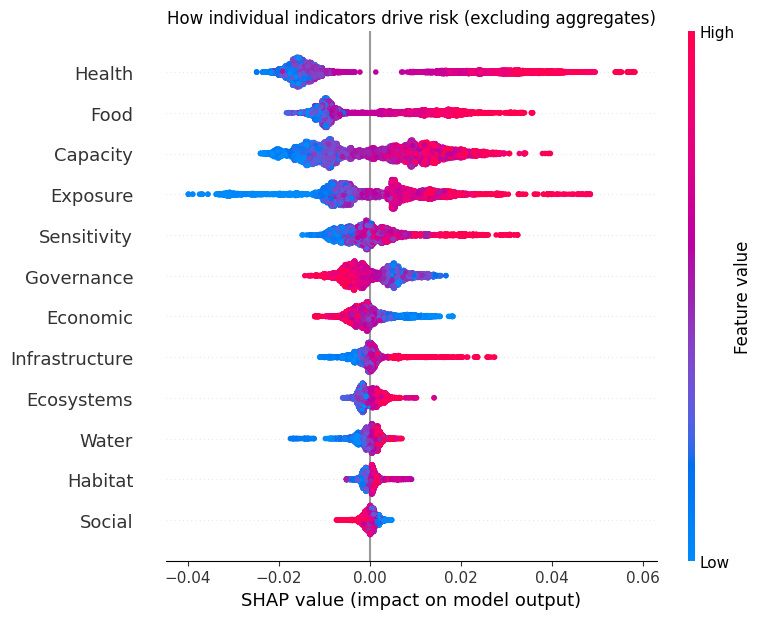

In [155]:
# Shows: high score → increases risk (right), low score → decreases risk (left)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",
    show=False
)
plt.title("How individual indicators drive risk (excluding aggregates)")
plt.tight_layout()
plt.show()

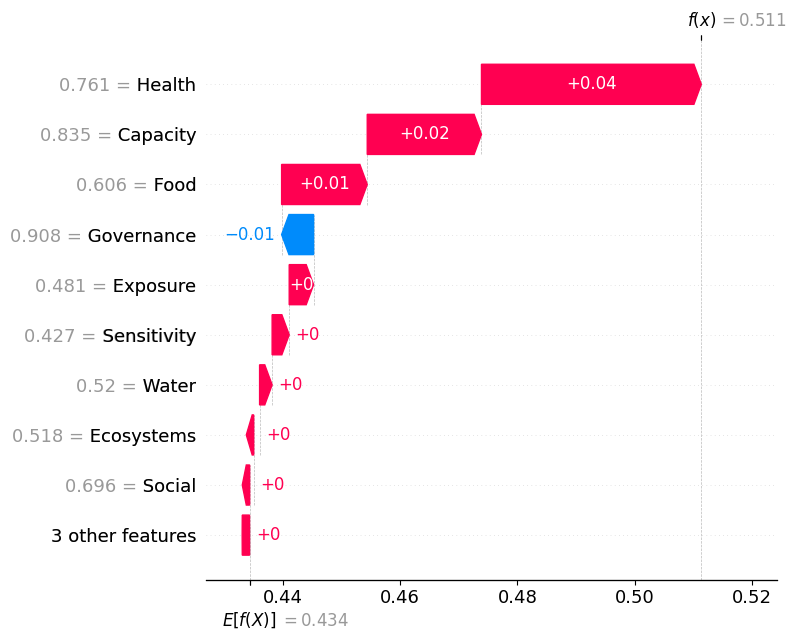

In [156]:
# Get SHAP values for a single country
country_idx = 10  # Pick a country
single_instance = X.iloc[country_idx:country_idx+1]
shap_values_single = explainer.shap_values(single_instance)

# Create waterfall plot correctly
explanation = shap.Explanation(
    values=shap_values_single[0],  # Get first (and only) row
    base_values=explainer.expected_value,
    data=single_instance.values[0],  # Convert to numpy array
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.show()

In [157]:
def explain_country_risk(country, model, explainer, data, year=None):

    # Get the requested row
    if year is None:
        row = data.loc[[country]].iloc[[0]]
    else:
        row = data.loc[[(country, year)]]

    # Prediction
    pred = model.predict(row)[0]

    # SHAP values
    shap_values = explainer.shap_values(row)

    explanation = (
        pd.DataFrame({
            "Feature": row.columns,
            "SHAP_Value": shap_values[0]
        })
        .sort_values("SHAP_Value", key=np.abs, ascending=False)
    )

    explanation["Contribution (%)"] = (
        explanation["SHAP_Value"].abs()
        / explanation["SHAP_Value"].abs().sum()
        * 100
    )

    print(f"\nPrediction: {pred:.4f}")
    print(f"Country: {row.index[0][0]}")
    print(f"Year: {row.index[0][1]}\n")

    return explanation

In [158]:
explain_country_risk("TCD", rf_corrected, explainer, X, year=2036)


Prediction: 0.5142
Country: TCD
Year: 2036



,Feature,SHAP_Value,Contribution (%)
7,Health,0.035845,34.915899
0,Capacity,0.019824,19.310147
4,Food,0.017507,17.053256
3,Exposure,0.012527,12.202487
1,Economic,-0.005505,5.361813
5,Governance,-0.004460,4.344731
2,Ecosystems,0.002028,1.975521
9,Sensitivity,0.001732,1.686900
8,Infrastructure,-0.001213,1.181700
11,Water,0.001154,1.124288


<Figure size 1000x600 with 0 Axes>

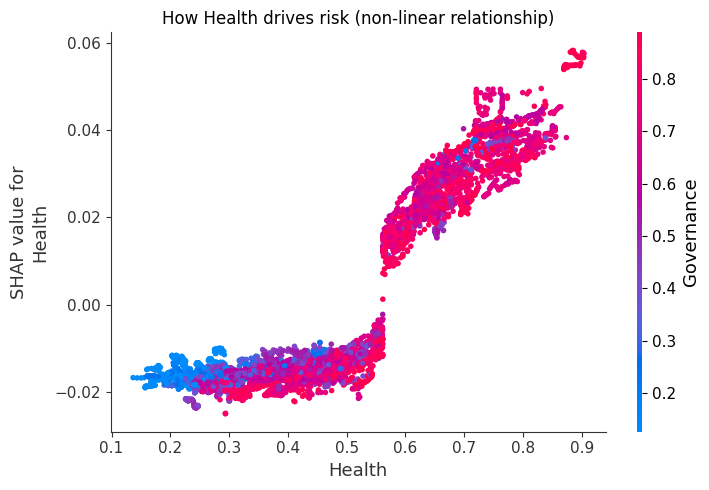

In [159]:
# Top contributor by SHAP impact
top_feature_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X,
    show=False
)
plt.title(f"How {top_feature_name} drives risk (non-linear relationship)")
plt.tight_layout()
plt.show()

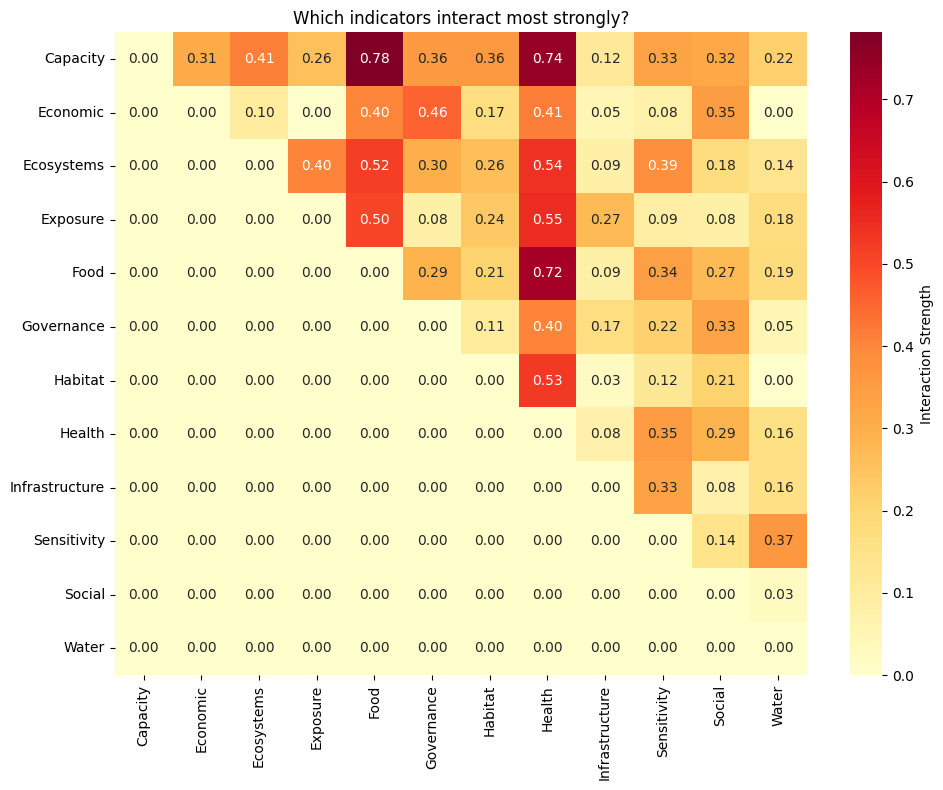

In [160]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============ FOCUS: Component-to-component interactions ============
# Exclude Vulnerability and Readiness from this analysis
components = [col for col in X.columns
              if col not in ['Vulnerability', 'Readiness']]

X_components_only = X[components]
shap_components = explainer.shap_values(X_components_only)


# ============ PLOT 2: Interaction heatmap ============
# Which component pairs interact most strongly?
interaction_matrix = np.zeros((len(components), len(components)))

for i, feat1 in enumerate(components):
    for j, feat2 in enumerate(components):
        if i < j:
            # Correlation between feature values × SHAP values = interaction proxy
            feat1_idx = X.columns.get_loc(feat1)
            feat2_idx = X.columns.get_loc(feat2)
            interaction = np.corrcoef(
                X_components_only[feat1].values,
                shap_components[:, feat2_idx]
            )[0, 1]
            interaction_matrix[i, j] = abs(interaction)

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(interaction_matrix, xticklabels=components, yticklabels=components,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Interaction Strength'})
plt.title("Which indicators interact most strongly?")
plt.tight_layout()
plt.show()

In [161]:
X

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
...                ...       ...         ...       ...       ...         ...   
ZWE     2036  0.588863  0.715092    0.499704  0.516912  0.572403    0.819337   
        2037  0.590097  0.714175    0.498560  0.516912  0.572504    0.818073   
        2038  0.591269  0.713353    0.497488  0.516912  0.572582    0.817073   
        2039  0.592382  0.712615    0.496494  0.516912  0.572643    0.816294   
        2040  0.593440  0.711952    0.495580  0.516912  0.572689    0.815697   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
...                ...       ...             ...          ...       ...   
ZWE     2036  0.560557  0.694479        0.315343     0.410264  0.858686   
        2037  0.560353  0.694478        0.317924     0.409847  0.858707   
        2038  0.560210  0.694477        0.320331     0.409477  0.858729   
        2039  0.560125  0.694476        0.322576     0.409147  0.858750   
        2040  0.560087  0.694476        0.324668     0.408854  0.858772   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
...                ...  
ZWE     2036  0.373934  
        2037  0.374200  
        2038  0.374514  
        2039  0.374835  
        2040  0.375134  

[8556 rows x 12 columns]

In [166]:
df

,country,year,indicator,value,source
0,AFG,1995,Capacity,0.893281,actual
1,AFG,1996,Capacity,0.893892,actual
2,AFG,1997,Capacity,0.894459,actual
3,AFG,1998,Capacity,0.890161,actual
4,AFG,1999,Capacity,0.885896,actual
...,...,...,...,...,...
128335,ZWE,2036,Water,0.373934,forecast
128336,ZWE,2037,Water,0.374200,forecast
128337,ZWE,2038,Water,0.374514,forecast
128338,ZWE,2039,Water,0.374835,forecast


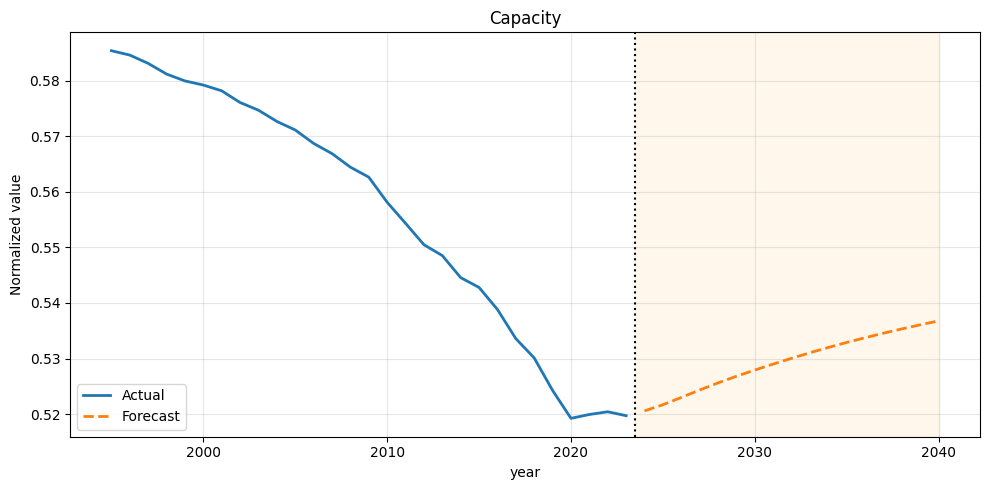

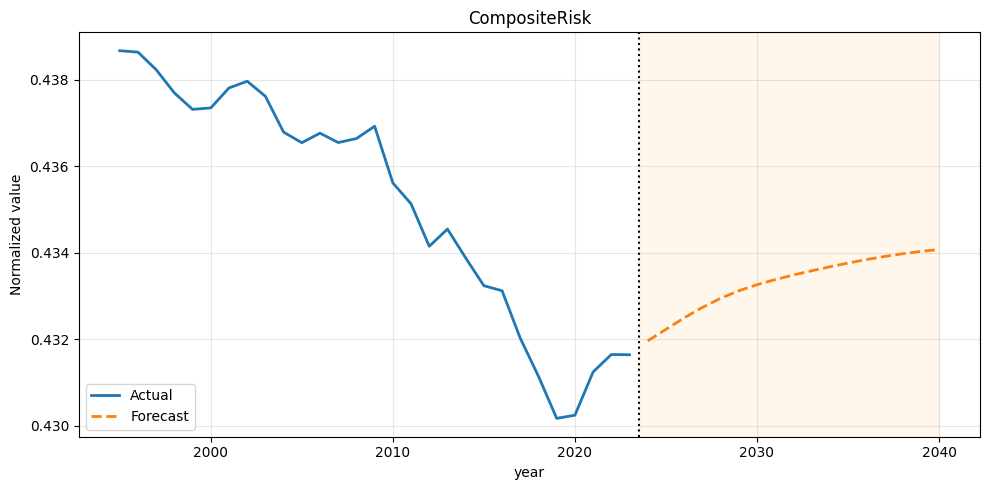

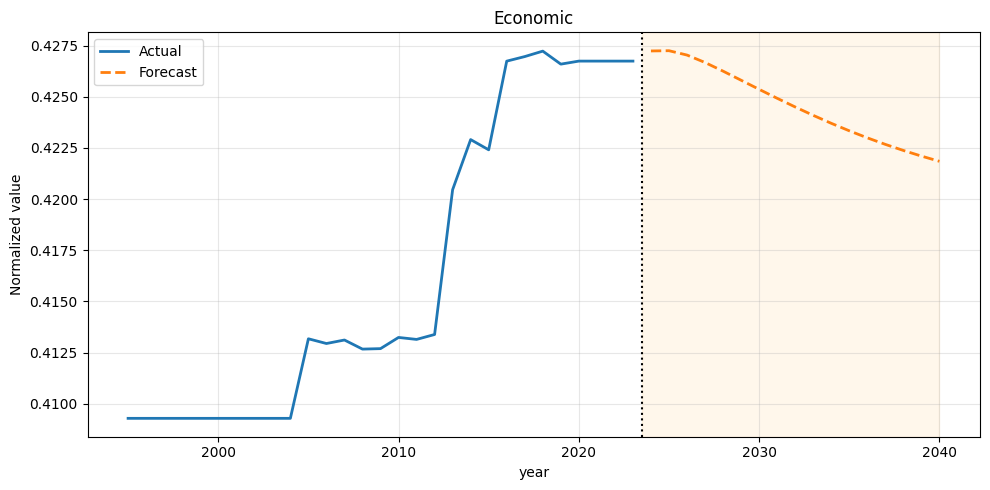

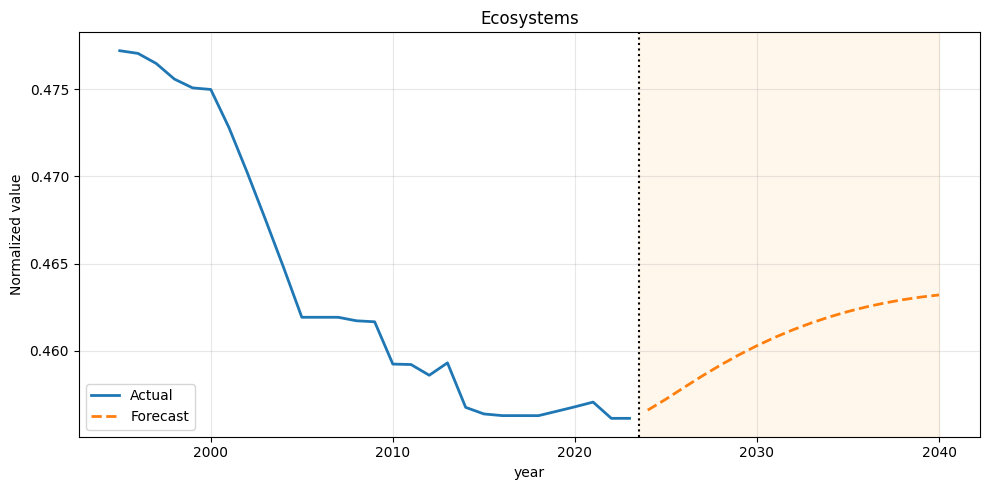

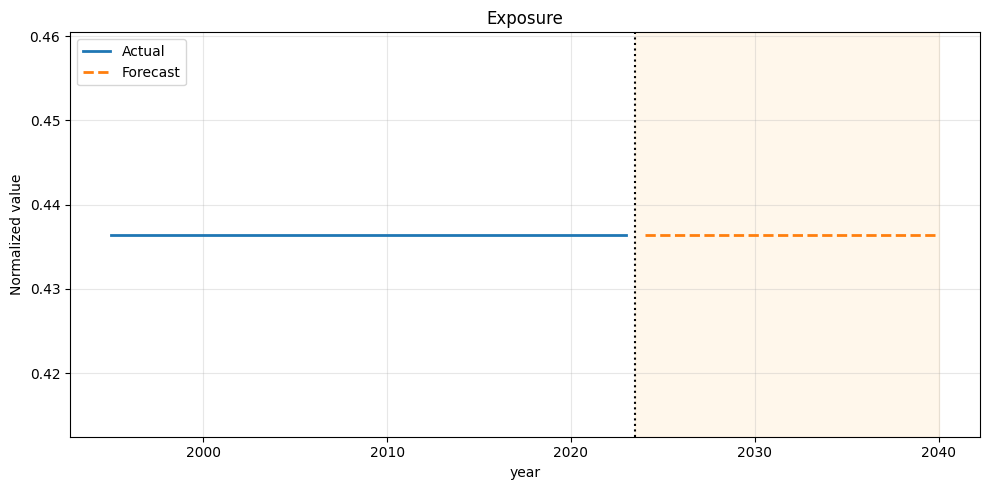

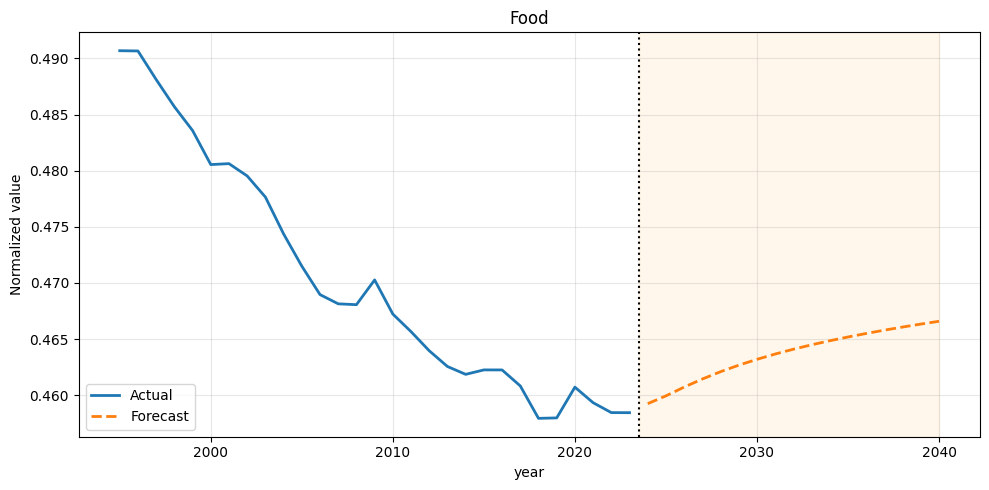

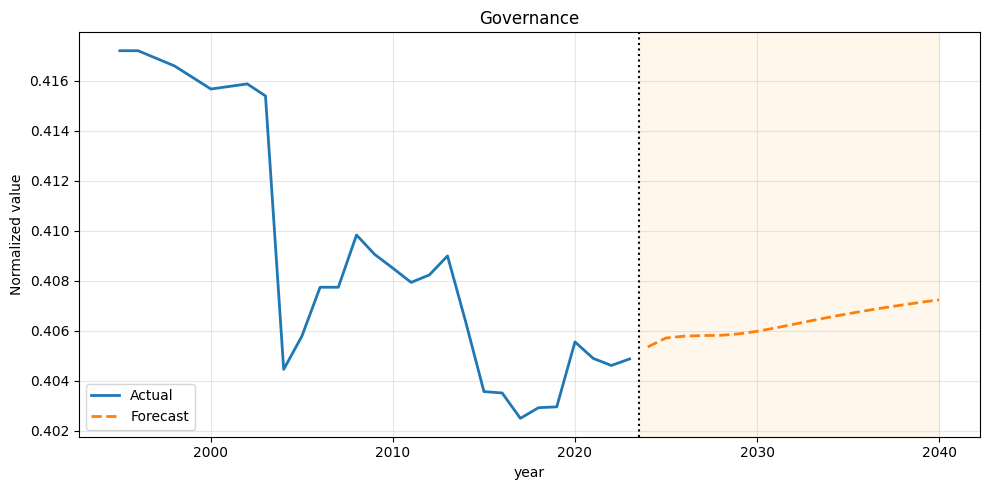

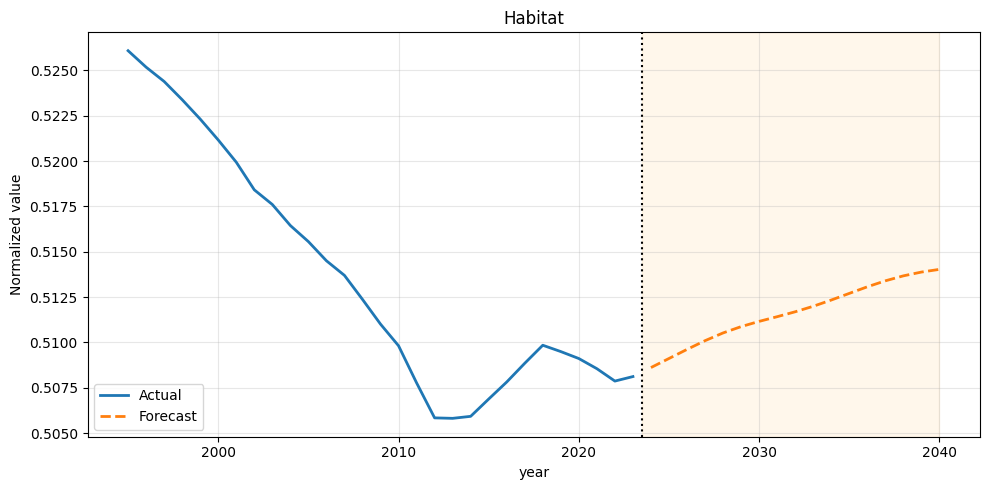

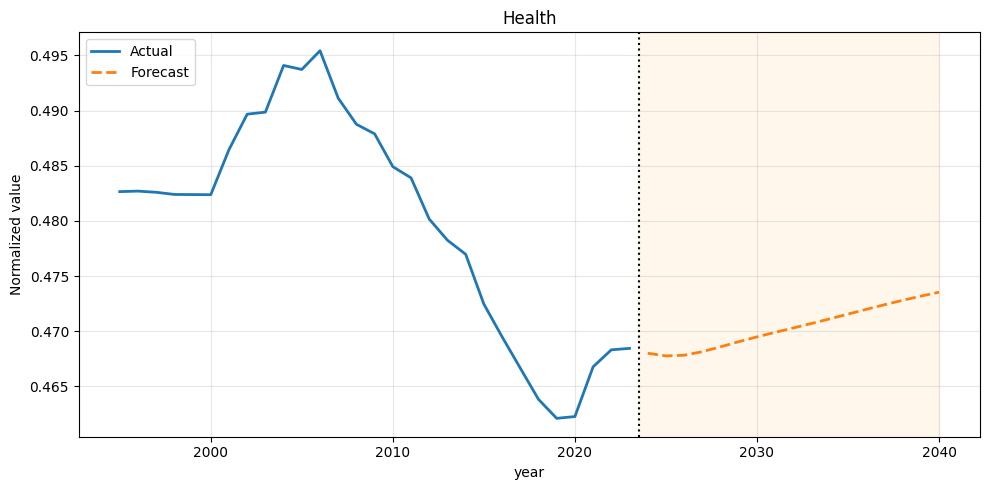

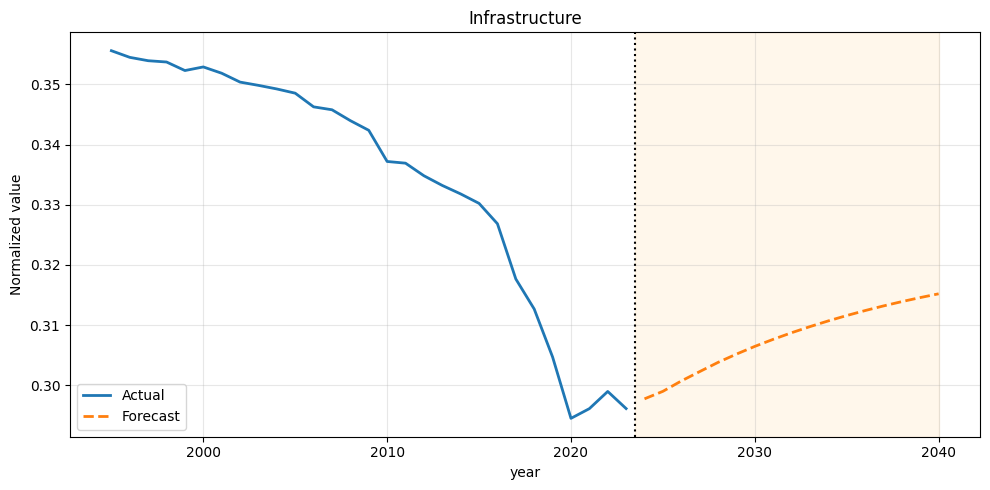

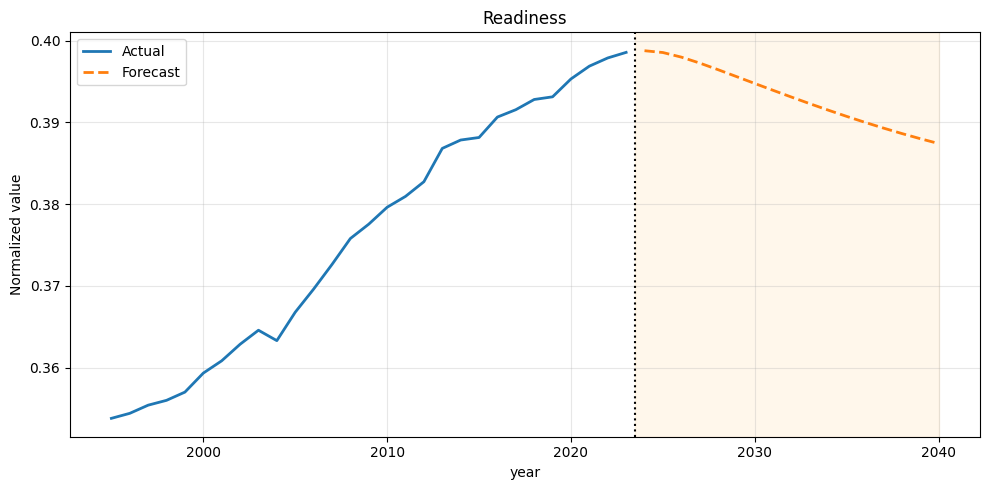

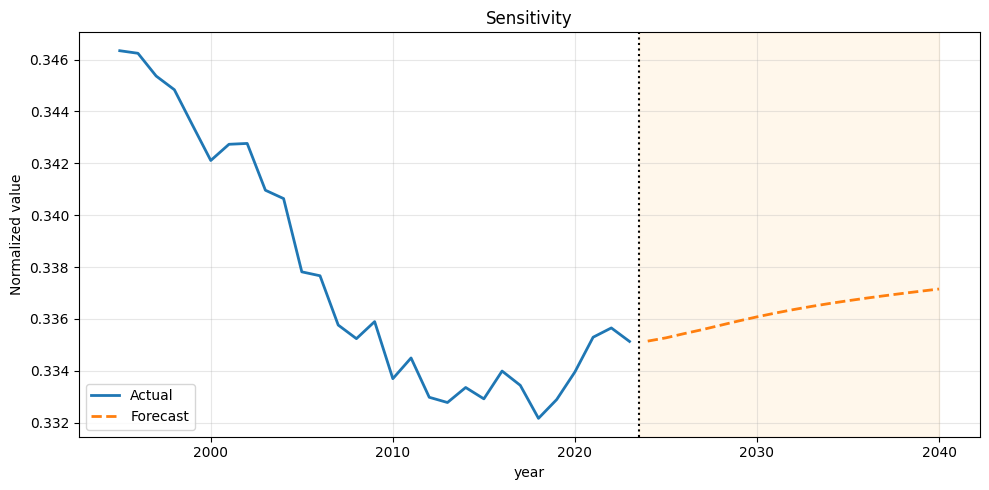

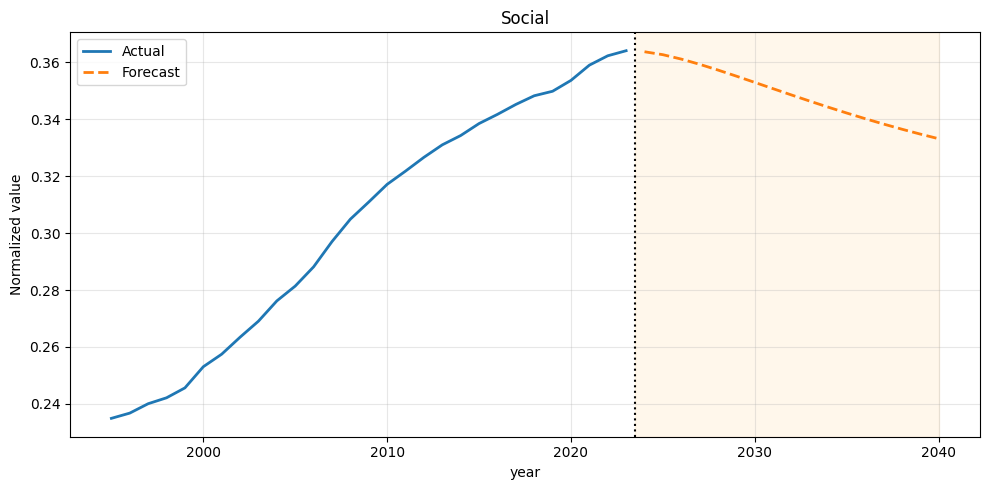

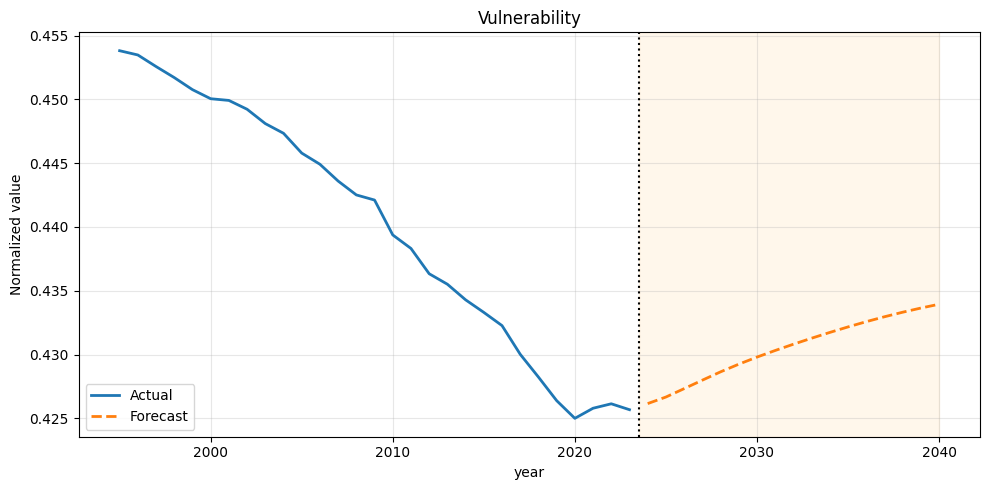

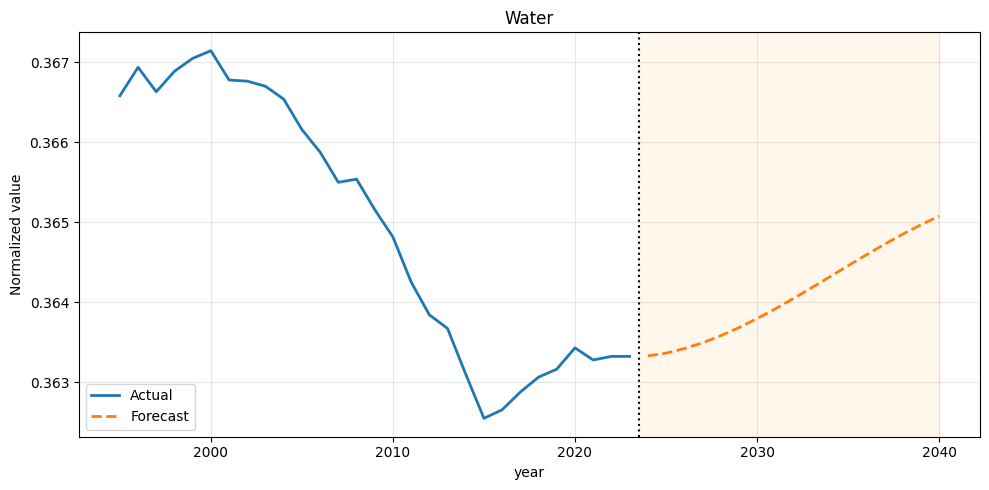

In [168]:
import matplotlib.pyplot as plt

actual_end = 2023

for indicator in sorted(df["indicator"].unique()):

    df_plot = (
        df[df["indicator"] == indicator]
        .groupby("year", as_index=False)["value"]
        .mean()      # average across countries
    )

    actual = df_plot[df_plot["year"] <= actual_end]
    forecast = df_plot[df_plot["year"] > actual_end]

    plt.figure(figsize=(10,5))

    # Actual values
    plt.plot(
        actual["year"],
        actual["value"],
        color="tab:blue",
        linewidth=2,
        label="Actual"
    )

    # Forecast
    plt.plot(
        forecast["year"],
        forecast["value"],
        color="tab:orange",
        linewidth=2,
        linestyle="--",
        label="Forecast"
    )

    # Separator
    plt.axvline(
        x=2023.5,
        color="black",
        linestyle=":",
        linewidth=1.5
    )

    # Optional forecast shading
    plt.axvspan(
        2023.5,
        df["year"].max(),
        color="orange",
        alpha=0.08
    )

    plt.title(indicator)
    plt.xlabel("year")
    plt.ylabel("Normalized value")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()